# 05 – Inference: Road Surface Crack Detection (Two-Stage Fine-Tuned U-Net)

**CSE445 – Road Damage Detection & Segmentation**

This notebook applies our **Stage 2 Fine-Tuned U-Net model** (`crack_stage2_unet_finetuned`) for road surface crack segmentation:
- **Input**: Any road recording video (`.mp4`, `.avi`, `.mov`) or single road image (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.webp`).
- **Model**: Two-Stage Pretrained + Fine-Tuned U-Net for thin fissure detection on dashcam/drone/handheld footage.
- **Output**: Full-resolution annotated image/video with solid white crack mask inside solid red filled bounding boxes (no opacity), and quantitative damage metrics.

In [1]:
# ============================================================
# 0. SETUP REPO ROOT & SYS.PATH (WORKS LOCAL & COLAB)
# ============================================================
import sys
import os
import base64
import importlib
from pathlib import Path

# Search upwards to find repo root containing 'support'
current = Path.cwd().resolve()
repo_root = None

for parent in [current, current.parent, current.parent.parent, Path('/content/Road_Damage_Project'), Path('/content')]:
    if (parent / 'support').is_dir():
        repo_root = parent
        break

if repo_root is None:
    repo_root = current.parent if current.name == 'notebooks' else current

repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

print(f"[OK] Repo root added to sys.path: {repo_root_str}")

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

import support.shared.inference
importlib.reload(support.shared.inference)  # Ensure latest module version is loaded
from support.shared.inference import CrackPredictor

# Safe standalone notebook video player function
def play_video_in_notebook(video_path, width=720):
    p = Path(video_path)
    if not p.exists():
        print(f"[Error] Video file not found: {video_path}")
        return
    with open(p, "rb") as f:
        video_bytes = f.read()
    b64 = base64.b64encode(video_bytes).decode("ascii")
    html_code = f'''
    <div style="text-align: center; margin: 15px 0;">
        <video width="{width}" controls autoplay loop style="border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.3);">
            <source src="data:video/mp4;base64,{b64}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
        <p style="color: #666; font-size: 12px; margin-top: 5px;">Playing: {p.name}</p>
    </div>
    '''
    display(HTML(html_code))



[OK] Repo root added to sys.path: D:\Road_Damage_Project


d:\anaconda3\envs\Thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda3\envs\Thesis\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4040)
  data = fetch_version_info()


### 1. Select Input Media (Image or Video) or Auto-Detect
- Set `MEDIA_PATH = None` to **automatically detect** available images or videos in `data/`.
- Or specify an exact image/video: e.g., `MEDIA_PATH = "data/road-surface-cracked-asphalt-damaged-260nw-2660583223.jpg"` or `MEDIA_PATH = "data/road_video.mp4"`.
- Use `MEDIA_PREFERENCE = 'image'`, `'video'`, or `'auto'` to choose which media type auto-detection should prioritize.

In [20]:
# ============================================================
# 1. CONFIGURE INPUT & INFERENCE SETTINGS (IMAGE OR VIDEO)
# ============================================================

# Set specific file path (Image or Video), or leave None for auto-detection:
MEDIA_PATH = None  # e.g., None, or "data/road_surface.jpg", or "data/road_video.mp4"

# Auto-detection preference when MEDIA_PATH is None: 'auto', 'image', or 'video'
MEDIA_PREFERENCE = 'auto'  # 'auto' (picks newest media), 'image', or 'video'

# Detection & Visual Settings for Stage 2 Fine-Tuned Model
THRESHOLD        = 0.20          # Probability threshold (0.30 - 0.40 is optimal for thin cracks)
ALPHA            = 0.35           # Mask opacity (1.0 = solid / no opacity / 100% opaque)
CRACK_COLOR      = (255, 0, 0) # Solid white crack mask
BOX_COLOR        = (255, 255, 0)     # Solid red full whole bounding box
OVERLAY_MODE     = 'both'        # 'both' (solid red full box + solid white mask), 'bbox' (red box only), or 'mask' (white mask only)
DRAW_BOXES       = True          # Draw solid red bounding boxes around detected cracks (True/False)
MIN_BOX_AREA     = 20            # Minimum pixel area for a crack blob to get a box (filters noise)
BOX_THICKNESS    = 2            # -1 = Full whole filled box; >0 = line thickness outline
DRAW_BOX_LABELS  = False         # Show confidence badge above boxes (True/False)
ENABLE_HUD       = False         # Video HUD status tag (True/False)
LAYOUT           = 'overlay'     # 'overlay' (blended mask) or 'side_by_side' (original + masked)
SHOW_LIVE_WINDOW = False         # Open real-time popup window on desktop (for video)
PLAY_IN_NOTEBOOK = True          # Embed playable HTML5 video player (for video)
MAX_FRAMES       = None          # Limit video frames (e.g., 150 for quick test) or None for full video

# ============================================================
# AUTO-DETECTION / RESOLUTION LOGIC
# ============================================================
VIDEO_EXTS = [".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv", ".webm"]
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"]

search_dirs = [
    repo_root / "data",
    repo_root / "data" / "crack",
    Path.cwd() / "data",
    Path.cwd(),
    repo_root,
    Path("/content"),
    Path("/content/drive/MyDrive/Road_Damage_Project/data"),
]

found_videos = []
found_images = []

for s_dir in search_dirs:
    if not s_dir.exists():
        continue
    for f in s_dir.iterdir():
        if f.is_file():
            suffix = f.suffix.lower()
            if "_masked" in f.stem.lower() or "_annotated" in f.stem.lower() or "_output" in f.stem.lower():
                continue
            if suffix in VIDEO_EXTS:
                if f.resolve() not in [v.resolve() for v in found_videos]:
                    found_videos.append(f)
            elif suffix in IMAGE_EXTS:
                if f.resolve() not in [img.resolve() for img in found_images]:
                    found_images.append(f)

found_videos.sort(key=lambda x: x.stat().st_mtime, reverse=True)
found_images.sort(key=lambda x: x.stat().st_mtime, reverse=True)

if MEDIA_PATH is not None and Path(MEDIA_PATH).exists():
    selected_path = Path(MEDIA_PATH).resolve()
    print(f"[Custom Input] Using user-specified media: {selected_path.name}")
else:
    if MEDIA_PREFERENCE == 'image':
        if found_images:
            selected_path = found_images[0]
            print(f"[Auto-Detected Image] Selected newest: {selected_path.name}")
        elif found_videos:
            selected_path = found_videos[0]
            print(f"[Fallback] No image found. Selected video: {selected_path.name}")
        else:
            raise FileNotFoundError("No input image or video found in data/ directories!")
    elif MEDIA_PREFERENCE == 'video':
        if found_videos:
            selected_path = found_videos[0]
            print(f"[Auto-Detected Video] Selected newest: {selected_path.name}")
        elif found_images:
            selected_path = found_images[0]
            print(f"[Fallback] No video found. Selected image: {selected_path.name}")
        else:
            raise FileNotFoundError("No input image or video found in data/ directories!")
    else:  # 'auto'
        all_found = found_images + found_videos
        all_found.sort(key=lambda x: x.stat().st_mtime, reverse=True)
        if all_found:
            selected_path = all_found[0]
            media_kind = 'Video' if selected_path.suffix.lower() in VIDEO_EXTS else 'Image'
            print(f"[Auto-Detected {media_kind}] Selected newest: {selected_path.name}")
        else:
            raise FileNotFoundError("No input image or video file found in data/ or workspace directory!")

MEDIA_PATH = str(selected_path)
is_video = selected_path.suffix.lower() in VIDEO_EXTS

print("=" * 60)
print(f"Selected Media : {selected_path.name}")
print(f"Full Path      : {MEDIA_PATH}")
print(f"Media Type     : {'Video' if is_video else 'Image'}")
print(f"Threshold      : {THRESHOLD} (Optimal for fine-tuned crack detection)")
print(f"Visual Mode    : {OVERLAY_MODE} (Full Solid Red Box, Solid White Mask: {DRAW_BOXES}, Min Area: {MIN_BOX_AREA}px)")
print(f"Alpha / Opacity: {ALPHA} (Solid / No Opacity)")
if is_video:
    print(f"HUD Overlay    : {ENABLE_HUD}")
    print(f"Max Frames     : {MAX_FRAMES if MAX_FRAMES else 'Entire video'}")
print("=" * 60)
if found_images:
    print(f"Available Images in data/: {[img.name for img in found_images]}")
if found_videos:
    print(f"Available Videos in data/: {[v.name for v in found_videos]}")

[Auto-Detected Video] Selected newest: Recording 2026-08-18 001617.mp4
Selected Media : Recording 2026-08-18 001617.mp4
Full Path      : D:\Road_Damage_Project\data\Recording 2026-08-18 001617.mp4
Media Type     : Video
Threshold      : 0.2 (Optimal for fine-tuned crack detection)
Visual Mode    : both (Full Solid Red Box, Solid White Mask: True, Min Area: 20px)
Alpha / Opacity: 0.35 (Solid / No Opacity)
HUD Overlay    : False
Max Frames     : Entire video
Available Images in data/: ['eda_crack_samples.png']
Available Videos in data/: ['Recording 2026-08-18 001617.mp4']


### 2. Initialize Crack Detection Model

In [21]:
# ============================================================
# 2. LOAD PREDICTOR & STAGE 2 WEIGHTS
# ============================================================

# Explicit path to Stage 2 Fine-Tuned Model checkpoint
stage2_ckpt = repo_root / "experiments" / "crack_stage2_unet_finetuned" / "best_model.pth"

if not stage2_ckpt.exists():
    print(f"[Notice] Stage 2 checkpoint not found at: {stage2_ckpt}")
    print("[Notice] Falling back to default available checkpoint...")
    predictor = CrackPredictor()
else:
    print(f"[OK] Loading Stage 2 Fine-Tuned weights from: {stage2_ckpt}")
    predictor = CrackPredictor(checkpoint_path=stage2_ckpt)

print("[OK] Predictor initialized successfully!")
print(f"Device     : {predictor.device}")
print(f"Checkpoint : {predictor.checkpoint_path}")

[OK] Loading Stage 2 Fine-Tuned weights from: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
[OK] Predictor initialized successfully!
Device     : cuda
Checkpoint : D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth


### 3. Run Inference (Image or Video)
Applies Stage 2 U-Net crack segmentation to the image or full-resolution video.

In [22]:
# ============================================================
# 3. EXECUTE INFERENCE
# ============================================================

result = predictor.process(
    input_path=MEDIA_PATH,
    threshold=THRESHOLD,
    crack_color=CRACK_COLOR,
    alpha=ALPHA,
    box_color=BOX_COLOR,
    overlay_mode=OVERLAY_MODE,
    draw_boxes=DRAW_BOXES,
    min_box_area=MIN_BOX_AREA,
    box_thickness=BOX_THICKNESS,
    draw_box_labels=DRAW_BOX_LABELS,
    layout=LAYOUT,
    hud=ENABLE_HUD,
    show_live_window=SHOW_LIVE_WINDOW,
    max_frames=MAX_FRAMES,
    show_progress=True
)

Processing Video: Frame 719/719 (100.0%) | Avg FPS: 31.8 | Crack %: 0.29%
[OK] Video processing complete in 22.63s (31.8 FPS)!
[OK] Masked video saved to: D:\Road_Damage_Project\data\Recording 2026-08-18 001617_crack_masked.mp4


### 4. Display Results & Visualizations
- **For Images**: Displays a 4-panel visual comparison (Original, Probability Heatmap, Crack Mask, Blended Overlay) + quantitative metrics.
- **For Videos**: Plays the masked video in the notebook and plots temporal crack coverage over time.

VIDEO CRACK DETECTION SUMMARY
Input Video            : Recording 2026-08-17 175016.mp4
Total frames processed : 429
Frames with damage     : 322 (75.1%)
Average crack coverage : 0.12%
Peak crack coverage    : 0.40%
Inference speed        : 61.6 FPS
Total processing time  : 6.96 seconds
Masked video saved to  : D:\Road_Damage_Project\data\Recording 2026-08-17 175016_crack_masked.mp4


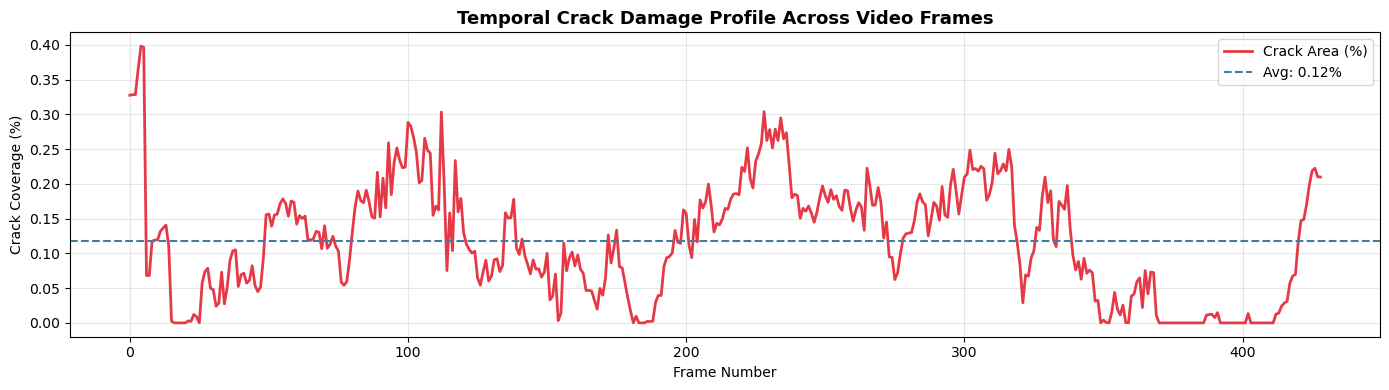

In [19]:
# ============================================================
# 4. DISPLAY INFERENCE RESULTS
# ============================================================

if not is_video:
    # --- IMAGE RESULTS --- 
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
    
    # 1. Original Image
    axes[0].imshow(result["original_image"])
    axes[0].set_title("Original Road Image", fontsize=13, fontweight="bold")
    axes[0].axis("off")
    
    # 2. Probability Heatmap
    im_prob = axes[1].imshow(result["prob_map"], cmap="magma", vmin=0, vmax=1)
    axes[1].set_title(f"Probability Heatmap (Max: {result['max_prob']:.2f})", fontsize=13, fontweight="bold")
    axes[1].axis("off")
    plt.colorbar(im_prob, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 3. Binary Mask
    axes[2].imshow(result["binary_mask"], cmap="gray")
    axes[2].set_title(f"Binary Mask (Thresh >= {THRESHOLD})", fontsize=13, fontweight="bold")
    axes[2].axis("off")
    
    # 4. Red Blended Overlay
    axes[3].imshow(result["overlay"])
    axes[3].set_title(f"Crack Overlay ({result['crack_pct']:.2f}% Area)", fontsize=13, fontweight="bold")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 60)
    print("IMAGE CRACK DETECTION RESULTS")
    print("=" * 60)
    print(f"Input Image         : {Path(result['image_path']).name}")
    print(f"Image Dimensions    : {result['original_image'].shape[1]} x {result['original_image'].shape[0]} px")
    print(f"Maximum Probability : {result['max_prob']:.4f}")
    print(f"Mean Probability    : {result['mean_prob']:.4f}")
    print(f"Crack Pixels        : {result['crack_pixels']:,}")
    print(f"Total Pixels        : {result['total_pixels']:,}")
    print(f"Predicted Crack Area: {result['crack_pct']:.2f}%")
    if 'output_path' in result or 'saved_to' in result:
        print(f"Masked Image Saved  : {result.get('output_path', result.get('saved_to'))}")
    print("=" * 60)

else:
    # --- VIDEO RESULTS & IN-NOTEBOOK PLAYBACK ---
    print("=" * 60)
    print("VIDEO CRACK DETECTION SUMMARY")
    print("=" * 60)
    print(f"Input Video            : {Path(result['input_path']).name}")
    print(f"Total frames processed : {result['total_frames_processed']}")
    print(f"Frames with damage     : {result['frames_with_cracks']} ({result['crack_frame_ratio']:.1f}%)")
    print(f"Average crack coverage : {result['avg_crack_pct']:.2f}%")
    print(f"Peak crack coverage    : {result['max_crack_pct']:.2f}%")
    print(f"Inference speed        : {result['avg_fps']:.1f} FPS")
    print(f"Total processing time  : {result['total_time_sec']:.2f} seconds")
    print(f"Masked video saved to  : {result['output_path']}")
    print("=" * 60)
    
    # 1. In-Notebook Video Player
    if PLAY_IN_NOTEBOOK and os.path.exists(result["output_path"]):
        print("\n--- Masked Video Playback ---")
        play_video_in_notebook(result["output_path"], width=720)
    
    # 2. Plot Temporal Crack Profile
    if result.get("crack_percentages_series"):
        plt.figure(figsize=(14, 4))
        plt.plot(result["crack_percentages_series"], color="#E63946", linewidth=2, label="Crack Area (%)")
        plt.axhline(y=result["avg_crack_pct"], color="#457B9D", linestyle="--", label=f"Avg: {result['avg_crack_pct']:.2f}%")
        plt.title("Temporal Crack Damage Profile Across Video Frames", fontsize=13, fontweight="bold")
        plt.xlabel("Frame Number")
        plt.ylabel("Crack Coverage (%)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


### 5. Quick One-Line Inference Helper
Run `run_crack_inference("path_to_image.jpg")` or `run_crack_inference("path_to_video.mp4")` anytime.

In [ ]:
def run_crack_inference(
    file_path,
    threshold=0.35,
    alpha=1.0,
    crack_color=(255, 255, 255),
    box_color=(255, 0, 0),
    overlay_mode='both',
    draw_boxes=True,
    min_box_area=30,
    box_thickness=-1,
    hud=False,
    layout='overlay',
    show_live=False,
):
    """
    One-line inference function for any road image or video with full whole solid red bounding boxes and solid white crack mask (no opacity).
    """
    return predictor.process(
        input_path=file_path,
        threshold=threshold,
        alpha=alpha,
        crack_color=crack_color,
        box_color=box_color,
        overlay_mode=overlay_mode,
        draw_boxes=draw_boxes,
        min_box_area=min_box_area,
        box_thickness=box_thickness,
        hud=hud,
        layout=layout,
        show_live_window=show_live
    )

print("[OK] Function 'run_crack_inference()' is ready for images & videos with full whole red bounding boxes and solid white crack mask!")

[OK] Function 'run_crack_inference()' is ready for images & videos!
